# Exercise 1: Getting to Know Your Data

For this exercise, we require a series of libraries. They are imported by executing the following code cell.

In [1]:
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 29.2 MB/s eta 0:00:0031m30.2 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 30.5 MB/s eta 0:00:00MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 31.3 MB/s eta 0:00:001m32.0 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.7/13.7 MB 27.3 MB/s eta 0:00:0031m27.8 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 30.8 MB/s eta 0:00:00 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 32.9 MB/s eta 0:00:00 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 817.9/817.9 kB 24.9 MB/s eta 0:00:00
  Attempting uninstall: squarify
    Found existing installation: squarify 0.4.4
    Uninstalling squarify-0.4.4:
      Successfully uninstalled squarify-0.4.4
  Attempting uninstall: numpy
    Found existing installation: numpy 2.1.1
    Uninstalling numpy-2.1.1:
      Successfully uninstalled numpy-2.1.1
  Attempting unins

In [2]:
# Import required libraries
import os
import tempfile
import sqlite3
import urllib.request
import squarify
import pywaffle
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

In addition to the libraries, we also need data with which we can familiarize ourselves during the exercise. For this purpose, we use the so-called AdventureWorks database, which is modeled after a fictional shop.

The following code cells download the database from GitHub (first cell) and then import the data required for this exercise into a pandas `DataFrame` (second cell).

In [3]:
# Create a temporary directory
dataset_folder = tempfile.mkdtemp()

# Build path to database
database_path = os.path.join(dataset_folder, "adventure-works.db")

# Get the database
urllib.request.urlretrieve(
    "https://github.com/FAU-CS6/KDD-Databases/raw/main/AdventureWorks/adventure-works.db",
    database_path,
)

# Open connection to the adventure-works.db
connection = sqlite3.connect(database_path)

In [4]:
# Create the clean DataFrame(s)
# Order DataFrame
order_df = pd.read_sql_query(
    "SELECT p.ProductID,p.Name,p.ProductNumber,p.MakeFlag,p.FinishedGoodsFlag,p.Color,p.SafetyStockLevel,"
    "p.ReorderPoint,p.StandardCost,p.ListPrice,p.Size,p.SizeUnitMeasureCode,p.WeightUnitMeasureCode,p.Weight,"
    "p.DaysToManufacture,p.ProductLine,p.Class,p.Style,p.ProductSubcategoryID,p.ProductModelID,p.SellStartDate,"
    "p.SellEndDate,p.DiscontinuedDate,d.PurchaseOrderID,d.PurchaseOrderDetailID,d.DueDate,d.OrderQty,d.ProductID,"
    "d.UnitPrice,d.ReceivedQty,d.RejectedQty,h.RevisionNumber,h.Status,h.EmployeeID,h.VendorID,h.ShipMethodID,"
    "h.OrderDate,h.ShipDate,h.SubTotal,h.TaxAmt,h.Freight,h.TotalDue,e.NationalIDNumber,e.LoginID,e.OrganizationNode,"
    "e.JobTitle,e.BirthDate,e.MaritalStatus,e.Gender,e.HireDate,e.SalariedFlag,e.VacationHours,e.SickLeaveHours,"
    "e.CurrentFlag,r.PersonType,r.NameStyle,r.Title,r.FirstName,r.MiddleName,r.LastName,r.Suffix,r.EmailPromotion,"
    "r.AdditionalContactInfo,r.Demographics "
    "FROM Product p "
    "JOIN PurchaseOrderDetail d ON p.ProductID = d.ProductID "
    "JOIN PurchaseOrderHeader h ON d.PurchaseOrderID = h.PurchaseOrderID "
    "JOIN Employee e ON h.EmployeeID = e.BusinessEntityID "
    "JOIN Person r ON e.BusinessEntityID = r.BusinessEntityID",
    connection,
    index_col="PurchaseOrderDetailID",
)

Currently we don't know anything about the `DataFrame` `order_df`. 
In order to gather an initial understanding of the structure of the `DataFrame`, it is useful to know the dimensions of the `DataFrame`. The corresponding information is stored in the shape property of a pandas `DataFrame`.

<div class="alert alert-block alert-info">

**Task 1:** 
    
Figure out the shape of `order_df`. You may take a look at the [pandas documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.shape.html) regarding the mentioned property.
    
</div>


In [6]:
# Get the shape of the DataFrame
order_df.shape

(8845, 63)

The output of shape is a tuple containing two values. It is of course important to know which number is the number of attributes and which is the number tuples/samples in our `DataFrame`.

<div class="alert alert-block alert-info">

**Task 2:** 

Take a look at the documentation to determine which element stands for the number of attributes and which for the number of tuples. 
    
</div>

The count of attributes/features: ?

The count of tuples/samples: ?

Now that we know the count of tuples and attributes in our `DataFrame`, we still do not know what data is contained in the data set.

In order to get a first impression in this respect, it can be useful to look at (a sample of) the `DataFrame`. The supposedly simplest method to make this possible is the `print()` function.

In [7]:
# Print the order_df
print(order_df)

                       ProductID                             Name  \
PurchaseOrderDetailID                                               
1                              1                  Adjustable Race   
2                            359               Thin-Jam Hex Nut 9   
3                            360              Thin-Jam Hex Nut 10   
4                            530                        Seat Post   
5                              4            Headset Ball Bearings   
...                          ...                              ...   
8841                         880          Hydration Pack - 70 oz.   
8842                         881   Short-Sleeve Classic Jersey, S   
8843                         882   Short-Sleeve Classic Jersey, M   
8844                         883   Short-Sleeve Classic Jersey, L   
8845                         884  Short-Sleeve Classic Jersey, XL   

                      ProductNumber  MakeFlag  FinishedGoodsFlag   Color  \
PurchaseOrderDetailID     

However, as you can see, this method outputs the entire content of the `DataFrame` without any specific layout. This can cause problems, especially with very large `DataFrames` and is therefore not recommended. It is far more common to use the `DataFrame` member function `head()`.

<div class="alert alert-block alert-info">

**Task 3:** 
    
Use the pandas documentation to familiarize yourself with `head()`, then apply it to the `order_df` to display the first 10 tuples.
    
</div>

In [8]:
# Use the head() function on the order_df while setting the number of rows displayed to 10
order_df.head(10)

,ProductID,Name,ProductNumber,MakeFlag,FinishedGoodsFlag,Color,SafetyStockLevel,ReorderPoint,StandardCost,ListPrice,...,PersonType,NameStyle,Title,FirstName,MiddleName,LastName,Suffix,EmailPromotion,AdditionalContactInfo,Demographics
PurchaseOrderDetailID,,,,,,,,,,,,,,,,,,,,,
1,1,Adjustable Race,AR-5381,0,0,None,1000,750,0.0,0.0,...,EM,0,None,Erin,M,Hagens,None,0,None,"<IndividualSurvey xmlns=""http://schemas.micros..."
2,359,Thin-Jam Hex Nut 9,HJ-1213,0,0,None,1000,750,0.0,0.0,...,EM,0,None,Fukiko,J,Ogisu,None,0,None,"<IndividualSurvey xmlns=""http://schemas.micros..."
3,360,Thin-Jam Hex Nut 10,HJ-1220,0,0,None,1000,750,0.0,0.0,...,EM,0,None,Fukiko,J,Ogisu,None,0,None,"<IndividualSurvey xmlns=""http://schemas.micros..."
4,530,Seat Post,SP-2981,0,0,None,500,375,0.0,0.0,...,EM,0,None,Eric,S,Kurjan,None,2,None,"<IndividualSurvey xmlns=""http://schemas.micros..."
5,4,Headset Ball Bearings,BE-2908,0,0,None,800,600,0.0,0.0,...,EM,0,None,Reinout,N,Hillmann,None,2,None,"<IndividualSurvey xmlns=""http://schemas.micros..."
6,512,HL Road Rim,RM-R800,0,0,None,800,600,0.0,0.0,...,EM,0,None,Mikael,Q,Sandberg,None,2,None,"<IndividualSurvey xmlns=""http://schemas.micros..."
7,513,Touring Rim,RM-T801,0,0,None,800,600,0.0,0.0,...,EM,0,None,Linda,P,Meisner,None,0,None,"<IndividualSurvey xmlns=""http://schemas.micros..."
8,317,LL Crankarm,CA-5965,0,0,Black,500,375,0.0,0.0,...,EM,0,None,Gordon,L,Hee,None,0,None,"<IndividualSurvey xmlns=""http://schemas.micros..."
9,318,ML Crankarm,CA-6738,0,0,Black,500,375,0.0,0.0,...,EM,0,None,Gordon,L,Hee,None,0,None,"<IndividualSurvey xmlns=""http://schemas.micros..."


As you can see, the representation by `head()` is easier to read. However, `head()` also has its limitations. For example, not all attributes are displayed when the number of attribute is large.

<div class="alert alert-block alert-info">

**Task 4:** 
    
List the names of all columns.
    
</div>

In [12]:
# Output a list of all columns
list(order_df.columns)

['ProductID',
 'Name',
 'ProductNumber',
 'MakeFlag',
 'FinishedGoodsFlag',
 'Color',
 'SafetyStockLevel',
 'ReorderPoint',
 'StandardCost',
 'ListPrice',
 'Size',
 'SizeUnitMeasureCode',
 'WeightUnitMeasureCode',
 'Weight',
 'DaysToManufacture',
 'ProductLine',
 'Class',
 'Style',
 'ProductSubcategoryID',
 'ProductModelID',
 'SellStartDate',
 'SellEndDate',
 'DiscontinuedDate',
 'PurchaseOrderID',
 'DueDate',
 'OrderQty',
 'ProductID',
 'UnitPrice',
 'ReceivedQty',
 'RejectedQty',
 'RevisionNumber',
 'Status',
 'EmployeeID',
 'VendorID',
 'ShipMethodID',
 'OrderDate',
 'ShipDate',
 'SubTotal',
 'TaxAmt',
 'Freight',
 'TotalDue',
 'NationalIDNumber',
 'LoginID',
 'OrganizationNode',
 'JobTitle',
 'BirthDate',
 'MaritalStatus',
 'Gender',
 'HireDate',
 'SalariedFlag',
 'VacationHours',
 'SickLeaveHours',
 'CurrentFlag',
 'PersonType',
 'NameStyle',
 'Title',
 'FirstName',
 'MiddleName',
 'LastName',
 'Suffix',
 'EmailPromotion',
 'AdditionalContactInfo',
 'Demographics']

For example, we did not see the columns `WeightUnitMeasureCode`, `Weight`, `DaysToManufacture`, `ProductLine`, `Class` and `Style` in the above execution of `head()`.  

<div class="alert alert-block alert-info">

**Task 5:** 

Show the first 10 tuples of the attributes `WeightUnitMeasureCode`, `Weight`, `DaysToManufacture`, `ProductLine`, `Class` and `Style`.
    
</div>

In [20]:
# Print the attributes WeightUnitMeasureCode, Weight, DaysToManufacture, ProductLine, Class
# and "Style" of the first ten attributes
order_df[["WeightUnitMeasureCode","Weight","DaysToManufacture","ProductLine","Class","Style"]].head(10)

,WeightUnitMeasureCode,Weight,DaysToManufacture,ProductLine,Class,Style
PurchaseOrderDetailID,,,,,,
1,None,NaN,0,None,None,None
2,None,NaN,0,None,None,None
3,None,NaN,0,None,None,None
4,None,NaN,0,None,None,None
5,None,NaN,0,None,None,None
6,G,400.0,0,None,None,None
7,G,460.0,0,None,None,None
8,None,NaN,0,None,L,None
9,None,NaN,0,None,M,None


Of course, it is a pity that all the attribute values shown are `0` in the `DaysToManufacture` attribute and `None` in the `ProductLine` attribute. However, this does not mean that this is the case for the entire `DataFrame`.

<div class="alert alert-block alert-info">

**Task 6:** 
    
Save all with `DaysToManufacture` higher than 0 into a new `DataFrame` called `order_dtm_not_zero_dataframe`. 
    
</div>

In [23]:
# Select all tuples with DaysToManufacture > 0
order_dtm_not_zero_dataframe = order_df[order_df["DaysToManufacture"] > 0]

<div class="alert alert-block alert-info">

**Task 7:** 

Display the columns `WeightUnitMeasureCode`, `Weight`, `DaysToManufacture`, `ProductLine`, `Class`, and `Style` of `order_dtm_not_zero_dataframe`. Limit the output to 10 tuples. 
    
</div>

In [24]:
# Print the attributes "WeightUnitMeasureCode", "Weight", "DaysToManufacture", "ProductLine", "Class"
# and "Style" of the first ten attributes of the new order_dtm_not_zero_dataframe
order_dtm_not_zero_dataframe[["WeightUnitMeasureCode","Weight","DaysToManufacture","ProductLine","Class","Style"]].head(10)

,WeightUnitMeasureCode,Weight,DaysToManufacture,ProductLine,Class,Style
PurchaseOrderDetailID,,,,,,
28,None,NaN,1,T,None,None
42,None,NaN,1,M,L,None
43,None,NaN,1,M,M,None
44,None,NaN,1,M,H,None
45,None,NaN,1,R,L,None
46,None,NaN,1,T,M,None
54,G,149.0,1,R,H,None
67,G,218.0,1,M,L,None
68,G,215.0,1,M,M,None


In addition to simply outputting data from the `DataFrame`, it can also be useful to examine some basic statistical descriptors. 

In this case we will focus here on the attributes `ReorderPoint`, `DaysToManufacture`, and `UnitPrice`. 

In [25]:
# Print the attributes "ReorderPoint", "DaysToManufacture", and "UnitPrice" of the first ten tuples
order_df[["ReorderPoint", "DaysToManufacture", "UnitPrice"]].head(10)

,ReorderPoint,DaysToManufacture,UnitPrice
PurchaseOrderDetailID,,,
1,750,0,50.2600
2,750,0,45.1200
3,750,0,45.5805
4,375,0,16.0860
5,600,0,57.0255
6,600,0,37.0860
7,600,0,26.5965
8,375,0,27.0585
9,375,0,33.5790


<div class="alert alert-block alert-info">

**Task 8:** 
    
Determine the mean for each of the three attributes and print it. (Help: [pandas documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.mean.html))

</div>

In [29]:
# Output the mean of "ReorderPoint"
order_df["ReorderPoint"].mean()

589.2929338609384

In [30]:
# Output the mean of "DaysToManufacture"
order_df["DaysToManufacture"].mean()

0.1348784624081402

In [31]:
# Output the mean of "UnitPrice"
order_df["UnitPrice"].mean()

34.74296411531939

<div class="alert alert-block alert-info">

**Task 9:** 
   
Determine the median for each of the three attributes and print it. (Help: [pandas documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.median.html))
    
</div>

In [32]:
# Output the median of "ReorderPoint"
order_df["ReorderPoint"].median()

750.0

In [33]:
# Output the median of "DaysToManufacture"
order_df["DaysToManufacture"].median()

0.0

In [34]:
# Output the median of "UnitPrice"
order_df["UnitPrice"].median()

39.2805

<div class="alert alert-block alert-info">

**Task 10:** 
    
Determine the minimum value for each of the three attributes and print it.
    
</div>

In [38]:
# Output the min of "ReorderPoint"
order_df["ReorderPoint"].min()

3

In [39]:
# Output the min of "DaysToManufacture"
order_df["DaysToManufacture"].min()

0

In [40]:
# Output the min of "UnitPrice"
order_df["UnitPrice"].min()

0.21

<div class="alert alert-block alert-info">

**Task 11:** 
    
Determine the maximum value for each of the three attributes and print it.

</div>

In [41]:
# Output the max of "ReorderPoint"
order_df["ReorderPoint"].max()

750

In [42]:
# Output the max of "DaysToManufacture"
order_df["DaysToManufacture"].max()

1

In [44]:
# Output the max of "UnitPrice"
order_df["UnitPrice"].max()

82.8345

<div class="alert alert-block alert-info">

**Task 12:** 
    
Determine the mode for each of the three attributes and print it.

</div>

In [45]:
# Output the mode of "ReorderPoint"
order_df["ReorderPoint"].mode()

0    750
Name: ReorderPoint, dtype: int64

In [46]:
# Output the mode of "DaysToManufacture"
order_df["DaysToManufacture"].mode()

0    0
Name: DaysToManufacture, dtype: int64

In [47]:
# Output the mode of "UnitPrice"
order_df["UnitPrice"].mode()

0    31.4895
1    48.2895
Name: UnitPrice, dtype: float64

<div class="alert alert-block alert-info">

**Task 13:** 
    
Determine the number of unique values for each of the three attributes and output it. (Help: Take a look at the function `nunique` in the pandas documentation.)

</div>

In [48]:
# Output the nunique of "ReorderPoint"
order_df["ReorderPoint"].nunique()

5

In [49]:
# Output the nunique of "DaysToManufacture"
order_df["DaysToManufacture"].nunique()

2

In [50]:
# Output the nunique of "UnitPrice"
order_df["UnitPrice"].nunique()

177

There are also methods in pandas that can be used to obtain multiple simple statistical values simultaneously for a `DataFrame`. An example is `describe`, which encapsulates the output of count, maximum, minimum, mean, standard deviation, and some quantiles in one function.

<div class="alert alert-block alert-info">
    
**Task 14:** 
    
Output the result for `describe` for each of the three attributes.

</div>

In [51]:
# Output the result for describe of "ReorderPoint"
order_df["ReorderPoint"].describe()

count    8845.000000
mean      589.292934
std       199.114087
min         3.000000
25%       375.000000
50%       750.000000
75%       750.000000
max       750.000000
Name: ReorderPoint, dtype: float64

In [52]:
# Output the result for describe of "DaysToManufacture"
order_df["DaysToManufacture"].describe()

count    8845.000000
mean        0.134878
std         0.341613
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: DaysToManufacture, dtype: float64

In [53]:
# Output the result for describe of "UnitPrice"
order_df["UnitPrice"].describe()

count    8845.000000
mean       34.742964
std        16.315439
min         0.210000
25%        25.420500
50%        39.280500
75%        45.444000
max        82.834500
Name: UnitPrice, dtype: float64

Another method is `agg`, with the help of which several self-defined statistical values are calculated for a `DataFrame` in a single call.

<div class="alert alert-block alert-info">
    
**Task 15:** 
    
Output the mean, median, minimum, maximum, and number of unique values again for each of the three attributes. This time, use `agg`.

</div>

In [60]:
# Output the result for agg of "ReorderPoint"
order_df["ReorderPoint"].agg(["mean","median","min","max","nunique"])

mean       589.292934
median     750.000000
min          3.000000
max        750.000000
nunique      5.000000
Name: ReorderPoint, dtype: float64

In [61]:
# Output the result for agg of "DaysToManufacture"
order_df["DaysToManufacture"].agg(["mean","median","min","max","nunique"])

mean       0.134878
median     0.000000
min        0.000000
max        1.000000
nunique    2.000000
Name: DaysToManufacture, dtype: float64

In [62]:
# Output the result for agg of "UnitPrice"
order_df["UnitPrice"].agg(["mean","median","min","max","nunique"])

mean        34.742964
median      39.280500
min          0.210000
max         82.834500
nunique    177.000000
Name: UnitPrice, dtype: float64

Even though the methods used here are fairly simple statistical methods, they can already tell us quite a bit about our data. 

<div class="alert alert-block alert-info">

**Task 16:** 
    
Consider and describe what can be said about the attribute `ReorderPoint` based on the statistical values obtained.

</div>

<div class="alert alert-block alert-info">

**Task 17:** 

Consider and describe what can be said about the `DaysToManufacture` attribute based on the statistical values obtained.
</div>

<div class="alert alert-block alert-info">

**Task 18:**
    
Consider and describe what can be said about the `UnitPrice` attribute based on the statistical values obtained.
</div>

The distribution of the individual values within the attributes is something we can not specific with these simple statistical values. A possibility to get more information about this is a histogram.

<div class="alert alert-block alert-info">

**Task 19:** 
    
Draw a histogram for `ReorderPoint`. Consider what number of bins might be appropriate. (Help: [pandas documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.hist.html))
</div>

(array([  57.,  315.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
        2574.,    0.,    0.,    0.,    0.,    0., 1277.,    0.,    0.,
           0., 4622.]),
 array([  3.  ,  40.35,  77.7 , 115.05, 152.4 , 189.75, 227.1 , 264.45,
        301.8 , 339.15, 376.5 , 413.85, 451.2 , 488.55, 525.9 , 563.25,
        600.6 , 637.95, 675.3 , 712.65, 750.  ]),
 <BarContainer object of 20 artists>)

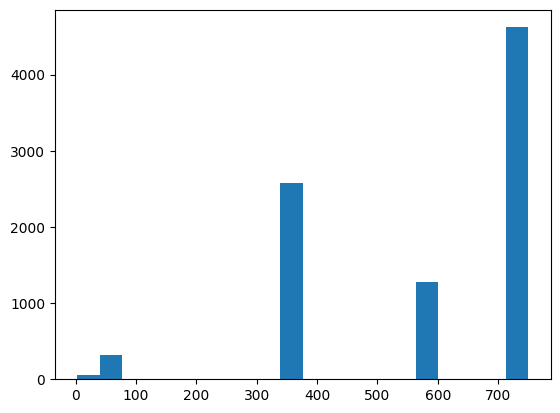

In [91]:
# Histogram for "ReorderPoint"
plt.hist(order_df["ReorderPoint"],bins=20)

<div class="alert alert-block alert-info">

**Task 20:**
    
Draw a histogram for `DaysToManufacture`. Consider what number of bins might be appropriate.
</div>

(array([7652., 1193.]),
 array([0. , 0.5, 1. ]),
 <BarContainer object of 2 artists>)

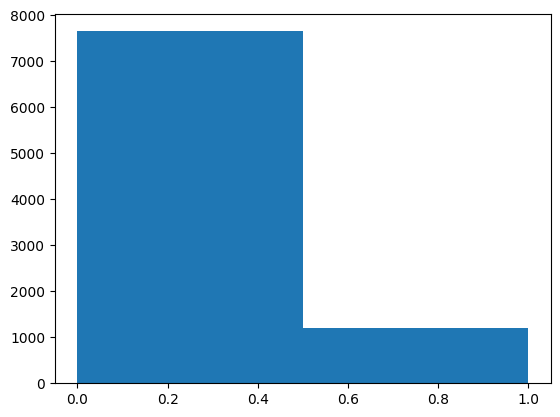

In [96]:
# Histogram for "DaysToManufacture"
plt.hist(order_df["DaysToManufacture"],bins=2)

<div class="alert alert-block alert-info">

**Task 21:**
    
Draw a histogram for `UnitPrice`. Consider what number of bins might be appropriate. 
</div>

(array([228., 353., 270., 170., 182., 211., 155., 134.,   1., 102., 223.,
        153., 177., 143., 307., 281., 259., 540., 633., 823., 873., 696.,
        654., 570., 254.,  31.,   0.,  82.,  33.,   0., 207.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0., 100.]),
 array([ 0.21     ,  2.2756125,  4.341225 ,  6.4068375,  8.47245  ,
        10.5380625, 12.603675 , 14.6692875, 16.7349   , 18.8005125,
        20.866125 , 22.9317375, 24.99735  , 27.0629625, 29.128575 ,
        31.1941875, 33.2598   , 35.3254125, 37.391025 , 39.4566375,
        41.52225  , 43.5878625, 45.653475 , 47.7190875, 49.7847   ,
        51.8503125, 53.915925 , 55.9815375, 58.04715  , 60.1127625,
        62.178375 , 64.2439875, 66.3096   , 68.3752125, 70.440825 ,
        72.5064375, 74.57205  , 76.6376625, 78.703275 , 80.7688875,
        82.8345   ]),
 <BarContainer object of 40 artists>)

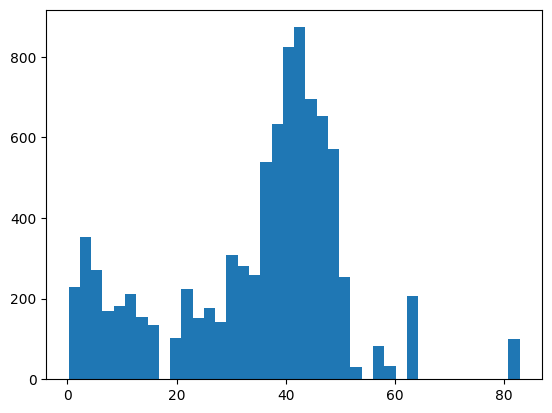

In [100]:
# Histogram for "UnitPrice"
plt.hist(order_df["UnitPrice"],bins=40)

It can be seen that it does not always make sense to choose the number of bins exactly like the number of unique values. 

Apart from that, we have to note that especially in the case of `UnitPrice`, insight is lost by merging multiple values. In such a case it can also be useful to look at boxplot and density curve instead of histogram.

<div class="alert alert-block alert-info">

**Task 22:**
    
Draw a boxplot diagram for `UnitPrice`. (Help: [pandas documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.box.html))
</div>


<Axes: >

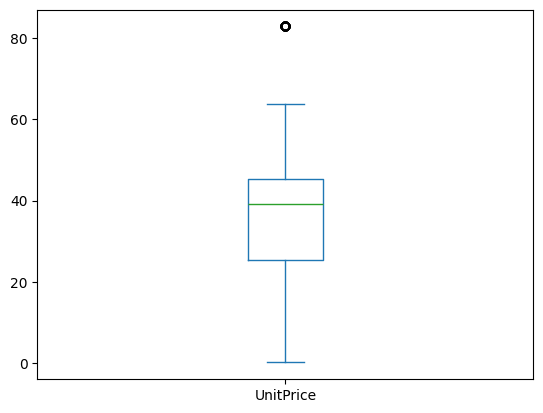

In [101]:
# Boxplot for "UnitPrice"
order_df["UnitPrice"].plot.box()

<div class="alert alert-block alert-info">

**Task 23:**
    
Draw a density diagram for "UnitPrice". (Help: [pandas documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.density.html))
</div>


<Axes: ylabel='Density'>

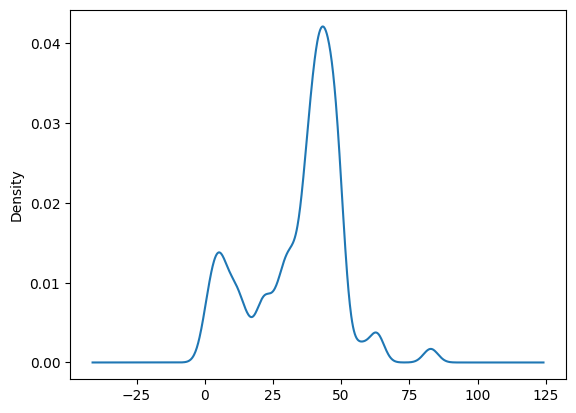

In [103]:
# Density curve for "UnitPrice"
order_df["UnitPrice"].plot.density()

While simple chart types such as histograms, boxplots and density plots can be directly used with pandas, a variety of libraries are available for more advanced visualizations. 



In the lecture you were introduced to Polar Plots, also called Radar Chart. In this type of chart, you look at multiple attributes of a single tuple.

<div class="alert alert-block alert-info">

**Task 24:**
    
Use Plotly's graph function `Scatterpolar` to output the prepared tuples within one polar plot. (Help: [Plotly Documentation](https://plotly.com/python/radar-chart/) and [Plotly API Reference](https://plotly.com/python-api-reference/generated/plotly.graph_objects.scatterpolar.html?highlight=scatterpolar#module-plotly.graph_objects.scatterpolar))
</div>

In [104]:
# Set the attributes to select
attributes = ["OrderQty", "ReceivedQty", "RejectedQty"]

# Prepare tuple_6, tuple_77, tuple_82
tuple_6 = pd.DataFrame(dict(r=order_df[attributes].iloc[6].values, theta=attributes))
tuple_77 = pd.DataFrame(dict(r=order_df[attributes].iloc[77].values, theta=attributes))
tuple_82 = pd.DataFrame(dict(r=order_df[attributes].iloc[82].values, theta=attributes))

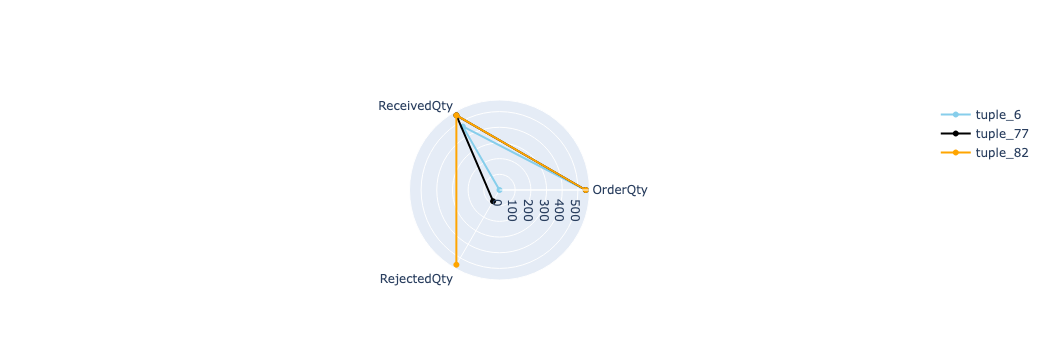

In [110]:
# Draw a single polar diagram for tuple_6, tuple_77 and tuple_82
import plotly.graph_objects as go


fig =go.Figure()

fig.add_trace(go.Scatterpolar(
    r = tuple_6['r'],
    theta = tuple_6['theta'],
    mode = 'lines+markers',
    name = 'tuple_6',
    line=dict(color = 'skyblue')
         
))
fig.add_trace(go.Scatterpolar(
    r = tuple_77['r'],
    theta = tuple_77['theta'],
    mode = 'lines+markers',
    name = 'tuple_77',
    line=dict(color = 'black')
         
))
fig.add_trace(go.Scatterpolar(
    r = tuple_82['r'],
    theta = tuple_82['theta'],
    mode = 'lines+markers',
    name = 'tuple_82',
    line=dict(color='orange')
         
))

fig.show()

One type of graph that we did not yet consider are scatter plots.

<div class="alert alert-block alert-info">

**Task 25:**
    
Use the internal pandas functions to create a scatter plot of the `OrderQty` and `ReceivedQty` attributes in `order_df`. (Help: [pandas Documentation](https://pandas.pydata.org/pandas-docs/dev/reference/api/pandas.DataFrame.plot.scatter.html))
</div>



In [ ]:
# Draw a scatter plot regarding "OrderQty" and "ReceivedQty"

Within a scatter plot, exactly two attributes are always displayed on different axes. In order to compare more than two attributes with each other, a scatter plot matrix is often used. 

<div class="alert alert-block alert-info">

**Task 26:**
    
Use seaborn to plot a pair plot that creates a scatter plot matrix of the attributes `OrderQty`, `ReceivedQty` and `RejectedQty` in `order_df`. (Help: [Seaborn Documentation](https://seaborn.pydata.org/generated/seaborn.pairplot.html#seaborn.pairplot))
</div>

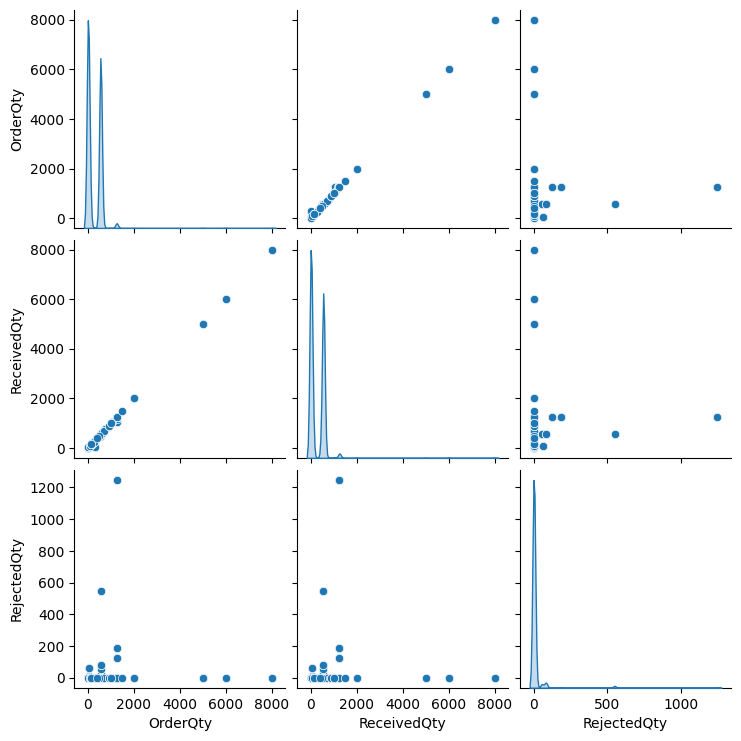

In [111]:
# Draw a scatter plot regarding "OrderQty", "ReceivedQty" and "RejectedQty"
sns.pairplot(order_df[["OrderQty", "ReceivedQty", "RejectedQty"]],diag_kind="kde")

Icon Based Diagrams are often used to show percentage relationships in an understandable way. 

For example, it can be used to highlight the gender distribution of employees working with our orders.

In [ ]:
# Get unique employees
orders_per_employee_df = (
    order_df.groupby(["EmployeeID", "FirstName", "MiddleName", "LastName", "Gender"])
    .size()
    .reset_index(name="Orders")
)

# Sort the DataFrame
orders_per_employee_df.sort_values("Orders", ascending=False, inplace=True)

# Show the head of the orders_per_employee_df
orders_per_employee_df.head(15)

In [ ]:
# Get the count of employees per gender
employees_per_gender_df = orders_per_employee_df.groupby(["Gender"]).size()

# Print the head of this new DataFrame
employees_per_gender_df

<div class="alert alert-block alert-info">

**Task 27:**
    
Use PyWaffle to draw an icon diagram regarding the genders of the employees. (Help: [PyWaffle Documentation](https://pywaffle.readthedocs.io/en/latest/examples/plot_with_characters_or_icons.html))
</div>

In [ ]:
# Draw the icon diagram

Even better than by Icon Diagrams, distributions can be displayed using tree maps. 

For example, a tree map can be used to display the count of orders processed per employee.

In [ ]:
# Print the head of orders_per_employee (again)
orders_per_employee_df.head(15)

<div class="alert alert-block alert-info">

**Task 28:**
    
Use Squarify to draw a tree map displaying the count of orders processed per employee. (Help: [Squarify Documentation](https://github.com/laserson/squarify#Usage))
</div>

In [ ]:
# Draw the tree map

In addition to data visualization, it can also be useful to determine the similarity of data.

Data similarity refers to the distance between two data sets. There are many different methods to determine distances between different types of data. 

In this chapter, we will focus on the distance between numeric data. More specifically, here, we compare previously selected and created tuples, namely `tuple_77` and `tuple_82`.

In [ ]:
tuple_77["r"]

In [ ]:
tuple_82["r"]

One of the most commonly used methods for calculating the distance between numerical values is the Manhattan distance, also called the L1 norm or City Block. A corresponding function that calculates the appropriate distance can be implemented relatively quickly using a for-loop.

In [ ]:
# Method to compute the Manhattan distance using a for-loop
def manhattan_distance(tuple_a, tuple_b):
    # We do not check for correct datatypes and same length of both tuples
    # However this should be done in a productive environment

    # Set the distance to 0
    distance = 0

    # Add the distance for each tuple
    for i in range(len(tuple_a)):
        difference = tuple_a[i] - tuple_b[i]
        absolute_difference = abs(difference)
        distance += absolute_difference

    # Return the distance
    return distance

In Python, however, one would normally take a more elegant approach and avoid the for-loop.

In [ ]:
# "Pythonic" method to compute the Manhattan distance
def manhattan_distance(tuple_a, tuple_b):
    # We do not check for correct datatypes and same length of both tuples
    # However this should be done in a productive environment

    # Convert lists to pandas Series
    if isinstance(tuple_a, list):
        a = pd.Series(tuple_a)
    else:
        a = tuple_a.copy()
    if isinstance(tuple_b, list):
        b = pd.Series(tuple_b)
    else:
        b = tuple_b.copy()

    # Compute the manhattan distance with a simple formula
    return (abs(a - b)).sum()

<div class="alert alert-block alert-info">

**Task 29:**
    
Use the defined function to compute the Manhattan distance between `tuple_77` and `tuple_82`.
</div>

In [ ]:
# Use the defined function to compute the Manhattan distance between tuple_77 and tuple_82

A second common variant is the Euclidean distance, also called L2 norm.

<div class="alert alert-block alert-info">

**Task 30:**
    
Complete the following source code to create a function to calculate the Euclidean distance and use it to calculate the Euclidean distance between `tuple_77` and `tuple_82`.
</div>

In [ ]:
# Method to compute the euclidean distance
def euclidean_distance(tuple_a, tuple_b):
    # ...
    return -1


# Use the defined function to compute the Euclidean distance between tuple_77 and tuple_82
# ...

Apparently, for `tuple_77` and `tuple_82`, the Manhattan distance and the Euclidean distance do not differ. But what about the following two lists?

In [ ]:
# Lists to compare
list_1 = [550, 550, 82]
list_2 = [82, 550, 550]

<div class="alert alert-block alert-info">

**Task 31:**
    
Compute the Manhattan distance and the Euclidean distance between `list_1` and `list_2`. 
</div>

In [ ]:
# Compute the manhattan distance

In [ ]:
# Compute the euclidean distance

<div class="alert alert-block alert-info">

**Task 32:**
    
Consider and explain why the distance measures did not differ for `tuple_77` and `tuple_82`, but did for `list_1` and `list_2`.
</div>

Write down your solution here:


Both the Manhattan distance and the Euclidean distance are special forms of the Minkowski distance. 

<div class="alert alert-block alert-info">

**Task 33:**    
    
Implement the Minkowski distance using the given code fragment. Use the resulting function to calculate the Manhattan distance and the Euclidean distance of list 1 and list 2 again.
</div>

In [ ]:
# Method to compute the minkowski distance
def minkowski_distance(tuple_a, tuple_b, h):
    # ...
    return -1


# Use the function to compute the Manhattan and the Euclidean distance between list_1 and list_2 and print them
# ...